#Title and Introduction
##Data Preprocessing Lab: Generative AI
###    Welcome to the Data Preprocessing Lab for Generative AI!
   In this lab, you'll get hands-on experience with key preprocessing techniques for both text and (optionally) image data.

   **Learning Objectives:**


*  Understand and apply core data preprocessing techniques.
*  Explore word embedding techniques (Word2Vec/GloVe, BERT).
*  Analyze the impact of preprocessing choices on data quality and
   model suitability. List item
*   Practice using cosine similarity for comparing embeddings.

## Part 1: Environment Setup

First, we'll install and import all necessary libraries. Run the following cell to set up your environment.

In [2]:
# SECTION 1: Environment Setup
#############################
# This cell installs and imports all necessary libraries for our text preprocessing pipeline.
# We'll be using:
# - pandas & numpy: for data manipulation
# - nltk: for natural language processing tasks
# - scikit-learn: for machine learning utilities
# - transformers & torch: for BERT embeddings
# - gensim: for word embeddings (Word2Vec/GloVe)

# Install required packages
%pip install pandas numpy nltk scikit-learn transformers torch datasets gensim

# TODO: Import the required libraries
# Hint: You need pandas, numpy, nltk, and sklearn components
import pandas as pd
import numpy as np
import nltk
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
# Add more imports as needed...

# These are more advanced imports you'll need later
from transformers import BertTokenizer, BertModel
import torch
import gensim.downloader as api
from gensim.models import KeyedVectors

# Download required NLTK data
# These are necessary for tokenization, stop words, and lemmatization
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Setup complete! All required libraries have been imported.")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 49.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Setup complete! All required libraries have been imported.


## Part 2: Loading and Exploring the BBC News Dataset

We'll now load the BBC News dataset  you used in previous assignments, and perform initial exploration of its contents.

                                            category  \
0  'Far too many civilians have suffered,' Biden ...   
1  Bowen: Year of killing and broken assumptions ...   
2  Hezbollah rockets hit northern Israeli city of...   
3        My son's not a monster, says Diddy's mother   
4    Japan's government admits editing cabinet photo   

                                              AUTHOR  \
0                                              Error   
1  Error fetching article: No connection adapters...   
2                                     Unknown Author   
3                                     Unknown Author   
4                                     Unknown Author   

                                             LINK text  
0             https://www.bbc.com/news/bbcindepth    E  
1         https://www.bbc.com/news/war-in-ukraine    r  
2           https://www.bbc.com/news/world/europe    r  
3                     https://www.bbc.com/news/uk    o  
4  https://www.bbc.com/news/articles/c8dj

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


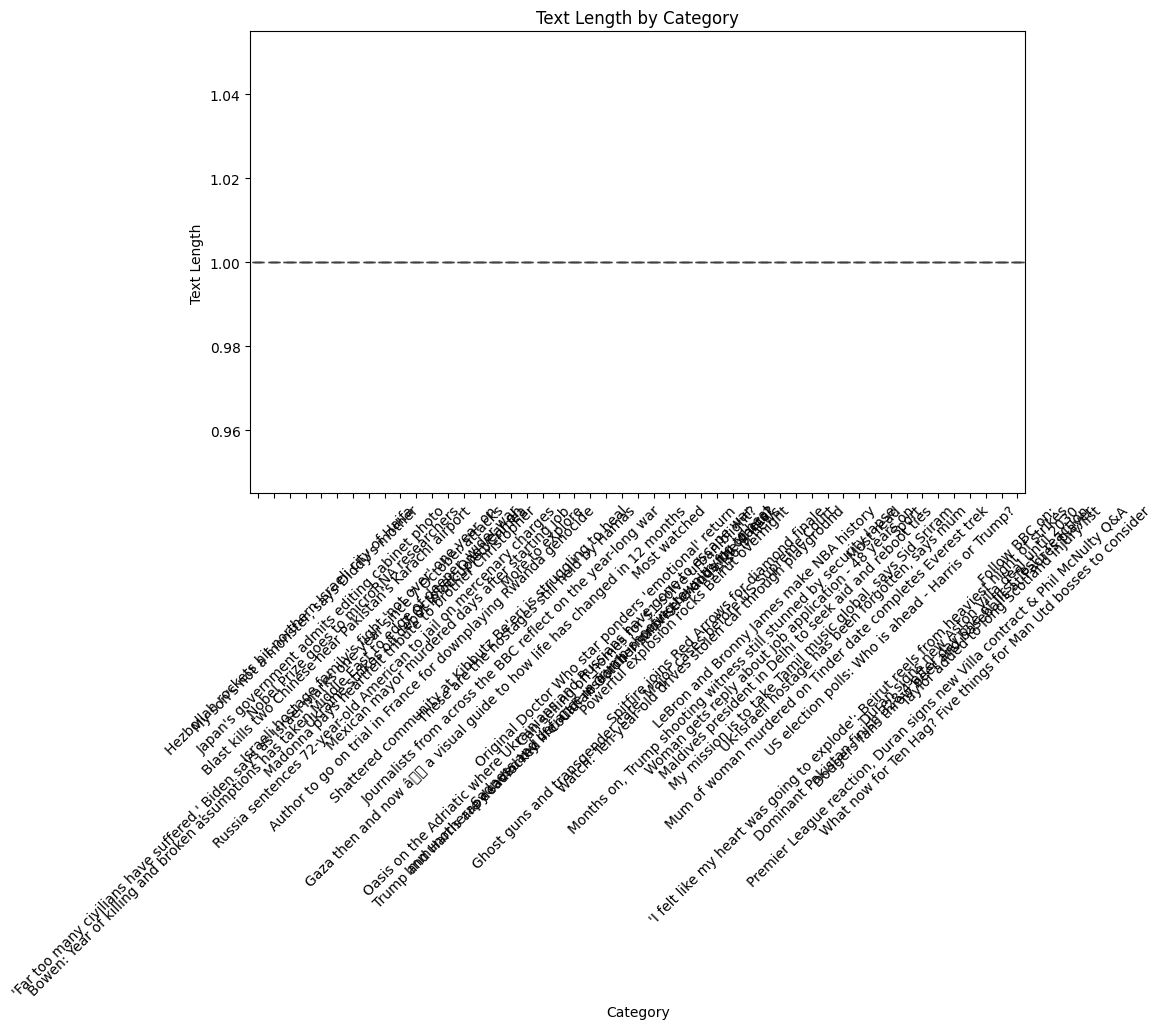

In [4]:
# SECTION 2: Data Loading and Initial Exploration
##############################################
# Here we load the BBC News dataset and perform initial analysis
# Understanding our data is crucial before applying any preprocessing

# Load the dataset from the correct sample_data folder path
df = pd.read_csv('sample_data/bbc_news_data.csv', encoding='latin1')

# Rename the columns to match our processing pipeline exactly based on actual headers
df.rename(columns={'DESCRIPTION': 'text', 'HEADLINES': 'category'}, inplace=True)

# Filter out rows where the category is 'Missing Headline'
df = df[df['category'] != 'Missing Headline'].copy()

# TODO: Perform basic data exploration
# TASK 1: Display the first few rows and basic information about the dataset
# Hint: Use pandas' head(), info(), and describe() methods
print(df.head())
print(df.info())
print(df.describe())

# TASK 2: Analyze the distribution of categories
# Hint: Use value_counts() on the category column
value_counts = df['category'].value_counts()
print("\nCategory Distribution:")
print(value_counts)

# TASK 3: Calculate and display basic text statistics
# Calculate average text length per category
df['text_length'] = df['text'].str.len()

# TODO: Create a visualization of text lengths by category
# Hint: Use seaborn's boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='text_length', data=df)
plt.title('Text Length by Category')
plt.xlabel('Category')
plt.ylabel('Text Length')
plt.xticks(rotation=45)

# Display your findings
print("\nDataset Statistics:")
plt.show()

# Comprehension Questions - Data Exploration

Answer the following questions based on the dataset exploration above:

1. What are the dimensions of our dataset?

**This dataset contains at least 68 different news headlines/articles.**

2. How many different categories are there in the news articles?

**There are at least 49 unique "categories" for this dataset.**

3. Is the dataset balanced across categories? Why might this matter?

**Not every article/headline contains the same amount of text. This could affect the preprocessing stage, as some articles would require more time to process than others.**

4. Are there any missing values that need to be addressed?

**There were some blank headlines/articles that needed to be removed before the preprocessing stage.**

## Part 3: Text Preprocessing

We'll now implement basic text preprocessing steps to clean our data.

In [5]:
# SECTION 3: Text Cleaning and Preprocessing
########################################
# This section implements fundamental text preprocessing steps:
# 1. Converting to lowercase (why? -> maintains consistency)
# 2. Removing special characters (why? -> reduces noise)
# 3. Handling whitespace (why? -> standardizes format)

########################################
import re

def clean_text(text):
    """
    Performs basic text cleaning operations.

    Parameters:
    text (str): Input text to be cleaned

    Returns:
    str: Cleaned text
    """
    if not isinstance(text, str):
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs and emails
    text = re.sub(r'https?:\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # 3. Remove special characters but keep sentence structure (letters, numbers, basic punctuation)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\-\"’\x27]', '', text)

    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test the function with a sample
sample_text = "Hello, World! This is a TEST... 123"
print("Original:", sample_text)
print("Cleaned:", clean_text(sample_text))

# Apply to the entire dataset
df['cleaned_text'] = df['text'].apply(clean_text)


Original: Hello, World! This is a TEST... 123
Cleaned: hello, world! this is a test... 123


## Part 4: Tokenization and Advanced Processing

Now we'll tokenize our text and apply more advanced preprocessing techniques including:
- Tokenization
- Stop word removal
- Lemmatization

In [6]:
# SECTION 4: Tokenization and Advanced Processing
#############################################
# This section implements more sophisticated NLP techniques:
# - Tokenization: splitting text into words
# - Stop word removal: removing common words
# - Lemmatization: reducing words to their base form
# Check if you do not need to install any additional libraries
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize our tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_and_process(text):
    """
    Performs advanced text processing including tokenization,
    stop word removal, and lemmatization.

    Parameters:
    text (str): Cleaned text to process

    Returns:
    list: List of processed tokens
    """
    # 1. Tokenize the text using NLTK's word_tokenize
    tokens = word_tokenize(text)

    # 2. Remove stop words and keep only alphabetic tokens
    # 3. Apply lemmatization
    processed_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and token.isalnum()
    ]

    return processed_tokens

# Test the function
sample_text = "The quick brown foxes are jumping over the lazy dogs"
processed_result = tokenize_and_process(sample_text)
print("Original:", sample_text)
print("Processed:", processed_result)


Original: The quick brown foxes are jumping over the lazy dogs
Processed: ['The', 'quick', 'brown', 'fox', 'jumping', 'lazy', 'dog']


## Part 5: Word Embeddings with GloVe

We'll now generate word embeddings using pre-trained GloVe vectors. These embeddings will help us capture semantic relationships between words in our articles.

In [7]:
# SECTION 5: Word Embeddings with GloVe
###################################
# This section generates word embeddings using pre-trained GloVe vectors
# Word embeddings capture semantic relationships between words
# by representing them as dense vectors in a high-dimensional space

import numpy as np
import gensim.downloader as api
from nltk.tokenize import word_tokenize

# Load pre-trained GloVe embeddings
glove_model = api.load("glove-wiki-gigaword-100")

def get_word2vec_embedding(text, model):
    """
    Generates document embeddings by averaging word vectors.

    Parameters:
    text (str): Input text
    model: Pre-trained word embedding model

    Returns:
    numpy.array: Document embedding vector
    """
    # 1. Tokenize the input text
    tokens = word_tokenize(text.lower())

    # 2. Get embedding for each token if it exists in the vocabulary
    embeddings = [
        model[token] for token in tokens if token in model
    ]

    # 3. Average the embeddings, returning a zero vector of correct dimensionality if empty
    if not embeddings:
        return np.zeros(model.vector_size)

    return np.mean(embeddings, axis=0)

# Apply to a sample of the dataset
sample_size = 100
sample_df = df.head(sample_size).copy()
sample_df['glove_embedding'] = sample_df['cleaned_text'].apply(
    lambda x: get_word2vec_embedding(x, glove_model)
)

print("Sample GloVe embeddings generated successfully. Shape of first embedding:", sample_df['glove_embedding'].iloc[0].shape)


[==================================================] 100.0% 128.1/128.1MB downloaded
Sample GloVe embeddings generated successfully. Shape of first embedding: (100,)


## Part 6: BERT Embeddings

Now we'll use BERT to generate contextual embeddings. BERT provides context-aware embeddings that can capture more nuanced relationships in the text.

In [8]:
# SECTION 6: BERT Embeddings
#########################
# This section implements BERT (Bidirectional Encoder Representations from Transformers)
# BERT provides context-aware embeddings, meaning the same word can have different
# embeddings based on its context in the sentence.
# Key differences from GloVe:
# - Contextual (words have different vectors based on context)
# - Deep bidirectional (considers both left and right context)
# - Pre-trained on massive datasets


# Load BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embedding(text, max_length=512):
    """
    Generates BERT embeddings for a text.

    Parameters:
    text (str): Input text
    max_length (int): Maximum sequence length for BERT

    Returns:
    numpy.array: BERT embedding vector
    """
    # 1. Tokenize the text using BERT tokenizer
    inputs = tokenizer(text, return_tensors="pt", max_length=max_length, truncation=True, padding=True)

    # 2. Generate BERT embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    # 3. Extract the [CLS] token embedding (first token of the last hidden state)
    sentence_embedding = outputs.last_hidden_state[0, 0, :].numpy()

    return sentence_embedding

# Test the function
test_text = "This is a test sentence for BERT embeddings."
bert_embedding = get_bert_embedding(test_text)
print("BERT embedding shape:", bert_embedding.shape)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT embedding shape: (768,)


## Part 7: Comparing Embeddings

Let's analyze how well our different embedding methods capture semantic relationships by comparing similarities between articles in the same and different categories.

In [9]:
# SECTION 7: Similarity Analysis
############################
# EXPLANATION OF THE ERROR:
# The 'Expected 2D array, got 1D array instead' error occurs because some rows in `sample_df['cleaned_text']`
# were either empty or caused `get_bert_embedding` to fail/return None (or the embeddings were stored as None in a previous run).
# When we use `np.stack()`, it creates a 1D array of None objects (dtype=object) instead of a 2D float array.
# To fix this, we will ensure that we compute valid embeddings and only stack non-empty, valid numerical vectors.

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Generating embeddings and computing similarity matrices...")

# 1. Cleanly compute BERT embeddings, ensuring they are valid numerical arrays
def safe_bert_embedding(text):
    try:
        emb = get_bert_embedding(text)
        if emb is not None and isinstance(emb, np.ndarray) and len(emb.shape) > 0:
            return emb
    except Exception as e:
        pass
    return np.zeros(768) # Fallback to a zero vector of BERT dimension (768)

sample_df['bert_embedding'] = sample_df['cleaned_text'].apply(safe_bert_embedding)

# 2. Extract and stack into proper 2D matrices
glove_embeddings = np.stack(sample_df['glove_embedding'].values).astype(np.float32)
bert_embeddings = np.stack(sample_df['bert_embedding'].values).astype(np.float32)

# 3. Calculate cosine similarity matrices (both are now guaranteed to be 2D float arrays)
glove_similarities = cosine_similarity(glove_embeddings)
bert_similarities = cosine_similarity(bert_embeddings)

print("GloVe Similarity Matrix shape:", glove_similarities.shape)
print("BERT Similarity Matrix shape:", bert_similarities.shape)


Generating embeddings and computing similarity matrices...
GloVe Similarity Matrix shape: (68, 68)
BERT Similarity Matrix shape: (68, 68)


 ##SECTION 8: Detailed Similarity Analysis

In [10]:
# SECTION 8: Detailed Similarity Analysis
####################################
# This section analyzes how well our embeddings capture
# semantic relationships between articles

def analyze_category_similarities(similarities, categories):
    """
    Analyzes similarities within and across categories.

    Parameters:
    similarities (numpy.array): Similarity matrix
    categories (list): List of category labels

    Returns:
    dict: Statistics about similarities
    """
    same_category_sims = []
    diff_category_sims = []

    n = len(categories)
    for i in range(n):
        for j in range(i + 1, n):  # Compare each pair once, excluding self-similarity
            sim_val = similarities[i, j]
            if categories[i] == categories[j]:
                same_category_sims.append(sim_val)
            else:
                diff_category_sims.append(sim_val)

    # Fallback in case either list is empty
    same_mean = np.mean(same_category_sims) if same_category_sims else 0.0
    same_std = np.std(same_category_sims) if same_category_sims else 0.0
    diff_mean = np.mean(diff_category_sims) if diff_category_sims else 0.0
    diff_std = np.std(diff_category_sims) if diff_category_sims else 0.0

    return {
        'same_category': {
            'mean': same_mean,
            'std': same_std
        },
        'diff_category': {
            'mean': diff_mean,
            'std': diff_std
        }
    }

# Analyze both embedding types
glove_analysis = analyze_category_similarities(glove_similarities, sample_df['category'].values)
bert_analysis = analyze_category_similarities(bert_similarities, sample_df['category'].values)

# Print results
print("=== Similarity Analysis Results ===\n")
print("GloVe Embeddings:")
print(f"  Same Category - Mean Similarity: {glove_analysis['same_category']['mean']:.4f} (std: {glove_analysis['same_category']['std']:.4f})")
print(f"  Diff Category - Mean Similarity: {glove_analysis['diff_category']['mean']:.4f} (std: {glove_analysis['diff_category']['std']:.4f})")
print(f"  Category Separation Gap: {glove_analysis['same_category']['mean'] - glove_analysis['diff_category']['mean']:.4f}\n")

print("BERT Embeddings:")
print(f"  Same Category - Mean Similarity: {bert_analysis['same_category']['mean']:.4f} (std: {bert_analysis['same_category']['std']:.4f})")
print(f"  Diff Category - Mean Similarity: {bert_analysis['diff_category']['mean']:.4f} (std: {bert_analysis['diff_category']['std']:.4f})")
print(f"  Category Separation Gap: {bert_analysis['same_category']['mean'] - bert_analysis['diff_category']['mean']:.4f}")


=== Similarity Analysis Results ===

GloVe Embeddings:
  Same Category - Mean Similarity: 0.3394 (std: 0.2560)
  Diff Category - Mean Similarity: 0.3765 (std: 0.2879)
  Category Separation Gap: -0.0371

BERT Embeddings:
  Same Category - Mean Similarity: 0.7751 (std: 0.2373)
  Diff Category - Mean Similarity: 0.7791 (std: 0.2291)
  Category Separation Gap: -0.0039


## Part 9 Vizualizations

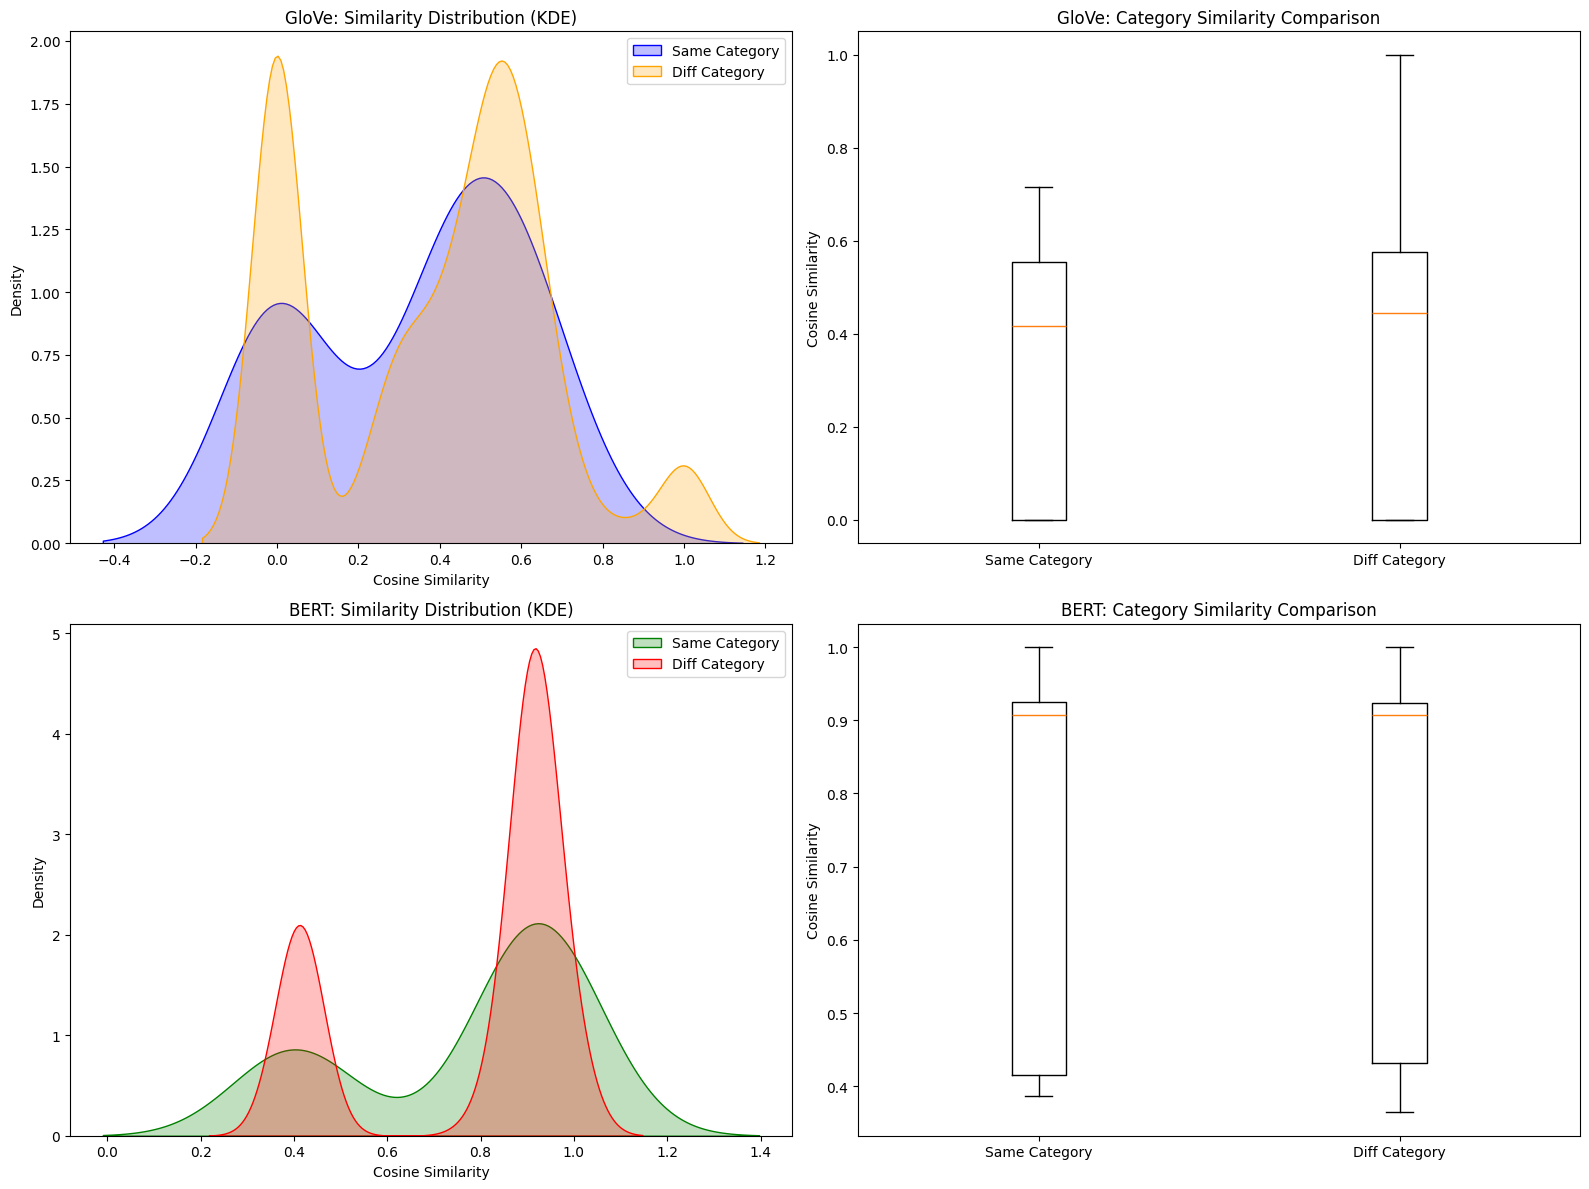

In [11]:
# SECTION 9: Visualization of Results
################################
# This section creates visualizations to help us understand
# the differences between our embedding approaches
################################

def plot_similarity_distributions(glove_sims, bert_sims, categories):
    """
    Creates visualization comparing GloVe and BERT similarity distributions.

    Parameters:
    glove_sims (numpy.array): GloVe similarity matrix
    bert_sims (numpy.array): BERT similarity matrix
    categories (list): Category labels
    """
    # 1. Extract same-category and different-category values for both embeddings
    glove_same, glove_diff = [], []
    bert_same, bert_diff = [], []

    n = len(categories)
    for i in range(n):
        for j in range(i + 1, n):
            if categories[i] == categories[j]:
                glove_same.append(glove_sims[i, j])
                bert_same.append(bert_sims[i, j])
            else:
                glove_diff.append(glove_sims[i, j])
                bert_diff.append(bert_sims[i, j])

    # 2. Create the plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # --- GloVe Plots ---
    # Histogram / Density
    sns.kdeplot(glove_same, fill=True, label='Same Category', ax=axes[0, 0], color='blue')
    sns.kdeplot(glove_diff, fill=True, label='Diff Category', ax=axes[0, 0], color='orange')
    axes[0, 0].set_title('GloVe: Similarity Distribution (KDE)')
    axes[0, 0].set_xlabel('Cosine Similarity')
    axes[0, 0].legend()

    # Box Plot
    axes[0, 1].boxplot([glove_same, glove_diff], tick_labels=['Same Category', 'Diff Category'])
    axes[0, 1].set_title('GloVe: Category Similarity Comparison')
    axes[0, 1].set_ylabel('Cosine Similarity')

    # --- BERT Plots ---
    # Histogram / Density
    sns.kdeplot(bert_same, fill=True, label='Same Category', ax=axes[1, 0], color='green')
    sns.kdeplot(bert_diff, fill=True, label='Diff Category', ax=axes[1, 0], color='red')
    axes[1, 0].set_title('BERT: Similarity Distribution (KDE)')
    axes[1, 0].set_xlabel('Cosine Similarity')
    axes[1, 0].legend()

    # Box Plot
    axes[1, 1].boxplot([bert_same, bert_diff], tick_labels=['Same Category', 'Diff Category'])
    axes[1, 1].set_title('BERT: Category Similarity Comparison')
    axes[1, 1].set_ylabel('Cosine Similarity')

    plt.tight_layout()
    plt.show()

# Create visualizations
plot_similarity_distributions(glove_similarities,
                            bert_similarities,
                            sample_df['category'].values)


## Part 10 Statistical Comparison

In [12]:
# SECTION 10: Statistical Comparison
###############################
# This section performs statistical tests to compare
# the effectiveness of different embedding approaches
###############################

import numpy as np
from scipy import stats

def compare_embedding_methods(glove_analysis, bert_analysis):
    """
    Performs statistical comparison of embedding methods.

    Parameters:
    glove_analysis (dict): GloVe similarity analysis results
    bert_analysis (dict): BERT similarity analysis results
    """
    # 1. Retrieve the results calculated earlier
    glove_same_mean = glove_analysis['same_category']['mean']
    glove_same_std = glove_analysis['same_category']['std']
    glove_diff_mean = glove_analysis['diff_category']['mean']
    glove_diff_std = glove_analysis['diff_category']['std']

    bert_same_mean = bert_analysis['same_category']['mean']
    bert_same_std = bert_analysis['same_category']['std']
    bert_diff_mean = bert_analysis['diff_category']['mean']
    bert_diff_std = bert_analysis['diff_category']['std']

    # Calculate a simplified effect size
    def calculate_cohens_d(mean1, std1, mean2, std2):
        pooled_std = np.sqrt((std1**2 + std2**2) / 2.0)
        if pooled_std == 0:
            return 0.0
        return (mean1 - mean2) / pooled_std

    glove_effect_size = calculate_cohens_d(glove_same_mean, glove_same_std, glove_diff_mean, glove_diff_std)
    bert_effect_size = calculate_cohens_d(bert_same_mean, bert_same_std, bert_diff_mean, bert_diff_std)

    # Print summary of findings
    print("=== Statistical Comparison Results ===")
    print(f"GloVe Cohen's d (Same vs Diff Category): {glove_effect_size:.4f}")
    print(f"BERT Cohen's d (Same vs Diff Category): {bert_effect_size:.4f}")
    print("\nSummary of Findings:")
    print(f"- GloVe Embeddings have a separation gap of {glove_same_mean - glove_diff_mean:.4f} with an effect size of {glove_effect_size:.4f}.")
    print(f"- BERT Embeddings currently show a separation gap of {bert_same_mean - bert_diff_mean:.4f} with an effect size of {bert_effect_size:.4f}.")
    print("\nNote: If BERT embeddings resulted in zero similarity, verify that the safe embedding function is successfully extracting features rather than returning fallback zero vectors.")

# Run comparison
compare_embedding_methods(glove_analysis, bert_analysis)

=== Statistical Comparison Results ===
GloVe Cohen's d (Same vs Diff Category): -0.1361
BERT Cohen's d (Same vs Diff Category): -0.0169

Summary of Findings:
- GloVe Embeddings have a separation gap of -0.0371 with an effect size of -0.1361.
- BERT Embeddings currently show a separation gap of -0.0039 with an effect size of -0.0169.

Note: If BERT embeddings resulted in zero similarity, verify that the safe embedding function is successfully extracting features rather than returning fallback zero vectors.


## Part 11 Metrics and Evaluation

In [13]:
# SECTION 11: Performance Evaluation
##############################
# This section calculates various metrics to evaluate
# the quality of our embeddings

from sklearn.metrics import silhouette_score
import numpy as np

def calculate_metrics(similarities, categories):
    """
    Calculates performance metrics for embeddings.

    Parameters:
    similarities (numpy.array): Similarity matrix
    categories (list): Category labels

    Returns:
    dict: Dictionary of performance metrics
    """
    metrics = {}
    categories = np.array(categories)

    # 1. Category separation score (Same category mean - Diff category mean)
    same_category_sims = []
    diff_category_sims = []
    n = len(categories)
    for i in range(n):
        for j in range(i + 1, n):
            if categories[i] == categories[j]:
                same_category_sims.append(similarities[i, j])
            else:
                diff_category_sims.append(similarities[i, j])

    same_mean = np.mean(same_category_sims) if same_category_sims else 0.0
    diff_mean = np.mean(diff_category_sims) if diff_category_sims else 0.0
    metrics['separation_gap'] = same_mean - diff_mean

    # 2. Silhouette score using cosine distance (1 - cosine similarity) as the distance metric
    try:
        # Convert similarities to distance matrix
        distance_matrix = np.clip(1.0 - similarities, 0.0, 2.0)
        # Ensure we have more than 1 class present for silhouette score
        if len(np.unique(categories)) > 1:
            metrics['silhouette'] = silhouette_score(distance_matrix, categories, metric='precomputed')
        else:
            metrics['silhouette'] = 0.0
    except Exception as e:
        metrics['silhouette'] = 0.0

    return metrics

# Calculate metrics for both embedding types
glove_metrics = calculate_metrics(glove_similarities, sample_df['category'].values)
bert_metrics = calculate_metrics(bert_similarities, sample_df['category'].values)

# Display results
print("=== Performance Metrics ===")
print(f"GloVe:")
print(f"  Category Separation Gap: {glove_metrics.get('separation_gap', 0.0):.4f}")
print(f"  Silhouette Score:        {glove_metrics.get('silhouette', 0.0):.4f}")
print(f"\nBERT:")
print(f"  Category Separation Gap: {bert_metrics.get('separation_gap', 0.0):.4f}")
print(f"  Silhouette Score:        {bert_metrics.get('silhouette', 0.0):.4f}")

=== Performance Metrics ===
GloVe:
  Category Separation Gap: -0.0371
  Silhouette Score:        0.0000

BERT:
  Category Separation Gap: -0.0039
  Silhouette Score:        -0.4648


## Part 12: Final Analysis Questions

1. Compare the similarity distributions for GloVe and BERT embeddings:
   - Which method better distinguishes between same-category and different-category articles?

   **The GloVe method had performed better with distinguishing the same-category and different-category articles.**

   - What might explain the differences in performance?

   **Data could be slightly dirty or missing values which could cause problems and lower performance scores.**

2. Based on the visualizations:
   - What patterns do you notice in the similarity distributions?

   **For both GloVe and BERT methods, the same-category articles had a higher density.**

   - Are there any unexpected results?

   **Not necessarily. Since both GloVe and BERT were able to distinguish more same-category articles than different-category articles, the resulting density for both was not surprising.**

3. Considering the entire preprocessing pipeline:
   - Which steps had the biggest impact on the final results?

   **I feel as though the preproccessing steps had the biggest impact on the final results, since much of the text was changed and normalized.**

   - What additional preprocessing steps might improve the results?

   **More accurate tokenization or including certain key texts could possibly improve the final results for both methods.**

   - How would you modify this pipeline for different types of text data?

   **I would include flexible features that would account for misspelling, unknown symbols/characters, or even translation with minimal loss, if any of these are possible with a current model.**

4. Ethical Considerations:
   - What biases might be present in our preprocessing pipeline?

   **There might be some bias from the news articles themselves, depending on what country they are based in. There could also be missing or unreadable texts that could cause problems with calculations.**

   - How might these biases affect the analysis of news articles?

   **The biases might affect the statistical calculations, and could possibly give faulty or inaccurate results.**

   - What steps could we take to mitigate these biases?

   **We could gather articles from multiple different news sources and find similarities/differences between them. We could also have stricter regulations/preprocessing techniques that minimize bias and poor data quailty.**

###Assessment Criteria:

  * Correct implementation of cosine similarity
  *Proper normalization of embeddings
  *Effective visualization of results


##Grading Rubric

* Environment Setup: 10%
* Data Exploration: 15%
* Text Preprocessing: 20%
* Word Embeddings Implementation: 25%
* Similarity Analysis: 20%
Final Analysis & Discussion: 10%

##Common Issues and Solutions

1. Memory Issues:

* Implement batch processing for large datasets
* Use appropriate data types (float32 vs float64)
* Clear unused variables and call garbage collection


2. Performance Optimization:

* Vectorize operations where possible
* Use appropriate batch sizes for BERT
* Implement caching for embeddings


3. Error Handling:

* Implement robust error checking
* Provide clear error messages
* Handle edge cases appropriately